# Correlated matching: log-odds weight vs Fowler $w=-\log p$

Rotated surface code Z-memory, circuit-level depolarizing, d=5, Tesseract decomposition. Three decoders on **common random numbers**:

- **MWPM** — uncorrelated baseline (Stim decomposition).
- **CM (log-odds)** — native PyMatching correlated matching, `decode_batch(enable_correlations=True, alpha=1.0)`. Reweighted edge gets $w=\log\frac{1-p}{p}\to 0$ at $p=0.5$.
- **CM (Fowler $-\log p$)** — the *same* two-pass, but the reweighted edge gets Fowler's $w=-\log p\to 0.693$ at $p=0.5$ ($p$ = the posterior $P(\mu\mid\nu)$). Only the reweight weight formula differs.

**Question:** does Fowler's convention (which floors the strong reweights at $\approx0.693$ instead of $0$) reduce the low-$p$ over-correction of log-odds CM?

**Speed note:** Fowler CM runs through the *Python* two-pass, so low $p$ (many shots for a few hundred errors) is slow. The default range is chosen to be feasible; add lower $p$ at your own patience.

In [6]:
%matplotlib inline
import os, sys, csv, time
import numpy as np
import matplotlib.pyplot as plt
import stim, pymatching

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
from NeuralCM.decompose_errors import decompose_errors_for_stim_surface_code_coords
from NeuralCM.two_pass_correlated_matching import TwoPassCorrelatedMatching

CLO, CHI = 1e-6, 0.499999
CFG = dict(distance=5, rounds=5,
           p_values=[2e-4, 4e-4],
           target_errors=200, max_shots=1000000_000_000, chunk=100_000, seed=12345,
           out_csv="data/cm_weight_convention_lowp.csv")
os.makedirs(os.path.join(ROOT, "data"), exist_ok=True)
os.makedirs(os.path.join(ROOT, "plots"), exist_ok=True)
print(CFG)

{'distance': 5, 'rounds': 5, 'p_values': [0.0002, 0.0004], 'target_errors': 200, 'max_shots': 1000000000000, 'chunk': 100000, 'seed': 12345, 'out_csv': 'data/cm_weight_convention_lowp.csv'}


In [7]:
def build(p):
    circ = stim.Circuit.generated(
        "surface_code:rotated_memory_z", distance=CFG["distance"], rounds=CFG["rounds"],
        after_clifford_depolarization=p, before_measure_flip_probability=p,
        after_reset_flip_probability=p, before_round_data_depolarization=p)
    dem = decompose_errors_for_stim_surface_code_coords(circ.detector_error_model(decompose_errors=False))
    dec = TwoPassCorrelatedMatching(dem, alpha=1.0, bypass_threshold=0)   # graph + Python two-pass
    g = dec.graph
    native = pymatching.Matching.from_detector_error_model(dem, enable_correlations=True)          # log-odds CM
    mwpm = pymatching.Matching.from_detector_error_model(
        circ.detector_error_model(decompose_errors=True), enable_correlations=False)
    return dict(circ=circ, g=g, m=dec._matching, adj=g.bidirectional_adjacency,
                occ=np.asarray(dec.occ), corr=np.asarray(dec.corr),
                cw=np.asarray(dec.current_weights), fault=g.fault_array, native=native, mwpm=mwpm)

def fowler_cm_batch(B, syn):
    """Hard CM (alpha=1) with reweight weight w = -log(posterior) instead of log-odds."""
    g, m, adj = B["g"], B["m"], B["adj"]
    occ, corr, cw, fault = B["occ"], B["corr"], B["cw"], B["fault"]
    sel_all = np.asarray(m.decode_batch(syn, enable_correlations=False), dtype=bool)
    pred = np.empty(len(syn), np.uint8)
    for s in range(len(syn)):
        sel = sel_all[s]; first = np.flatnonzero(sel)
        if first.size == 0:
            pred[s] = np.uint8((sel @ fault) % 2); continue
        nw = cw.copy()
        for node in np.flatnonzero(g.compute_action_mask(first)):
            best = cw[node]
            for nbr, e in adj.get(node, []):
                if sel[nbr]:
                    ip = min(max(corr[e] / occ[nbr], CLO), CHI)   # posterior P(mu|nu)
                    w = -np.log(ip)                               # Fowler weight
                    if w < best:
                        best = w
            nw[node] = best
        ed = np.asarray(m.decode(syn[s], enable_correlations=False,
                                 edge_reweights=g.build_edge_reweights(nw, cw)), dtype=np.int64)
        pred[s] = np.uint8((ed @ fault) % 2)
    return pred

print("helpers ready")

helpers ready


## Run the sweep

In [8]:
results = []
t_all = time.time()
for p in CFG["p_values"]:
    B = build(p)
    sampler = B["circ"].compile_detector_sampler(seed=CFG["seed"])
    e_mwpm = e_log = e_fow = 0
    shots = 0
    t0 = time.time()
    while shots < CFG["max_shots"] and e_log < CFG["target_errors"]:
        syn, obs = sampler.sample(shots=CFG["chunk"], separate_observables=True)
        obs = obs.flatten().astype(np.uint8)
        e_mwpm += int(np.sum(np.asarray(B["mwpm"].decode_batch(syn))[:, 0] != obs))
        e_log += int(np.sum(np.asarray(B["native"].decode_batch(syn, enable_correlations=True))[:, 0] != obs))
        e_fow += int(np.sum(fowler_cm_batch(B, syn) != obs))
        shots += CFG["chunk"]
    def std(e):
        l = e / shots; return (l * (1 - l) / shots) ** 0.5
    r = dict(p=p, shots=shots, mwpm=e_mwpm / shots, mwpm_s=std(e_mwpm),
             log=e_log / shots, log_s=std(e_log), fow=e_fow / shots, fow_s=std(e_fow))
    results.append(r)
    print(f"p={p:<7g} shots={shots:>10,} | MWPM={r['mwpm']:.3e}  CM_log={r['log']:.3e}  CM_fowler={r['fow']:.3e} | "
          f"fowler/log={r['fow']/r['log']:.3f}  log/MWPM={r['log']/r['mwpm']:.3f}  fowler/MWPM={r['fow']/r['mwpm']:.3f} | "
          f"{time.time()-t0:.0f}s", flush=True)

with open(os.path.join(ROOT, CFG["out_csv"]), "w", newline="") as f:
    w = csv.writer(f); w.writerow(["p", "decoder", "shots", "ler", "ler_std"])
    for r in results:
        for name, k in (("mwpm", "mwpm"), ("cm_logodds", "log"), ("cm_fowler", "fow")):
            w.writerow([r["p"], name, r["shots"], r[k], r[k + "_s"]])
print(f"\nsaved {CFG['out_csv']} | total {time.time()-t_all:.0f}s")

p=0.0002  shots=196,900,000 | MWPM=1.178e-06  CM_log=1.016e-06  CM_fowler=8.989e-07 | fowler/log=0.885  log/MWPM=0.862  fowler/MWPM=0.763 | 3579s
p=0.0004  shots=31,000,000 | MWPM=8.387e-06  CM_log=6.452e-06  CM_fowler=6.065e-06 | fowler/log=0.940  log/MWPM=0.769  fowler/MWPM=0.723 | 744s

saved data/cm_weight_convention_lowp.csv | total 4323s


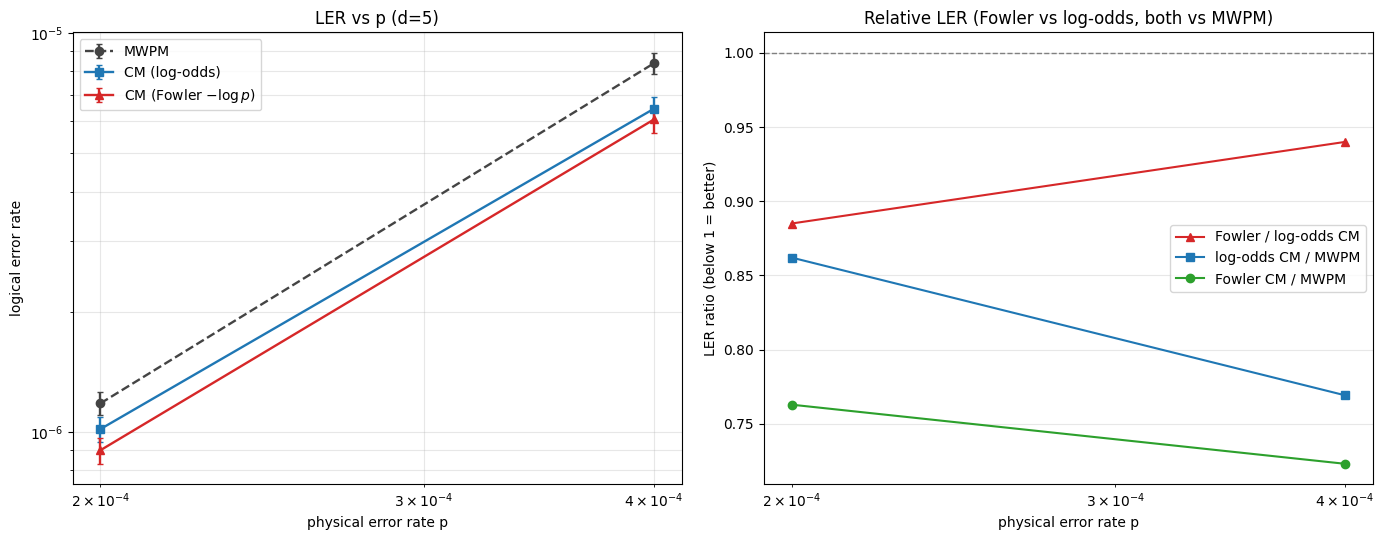

saved plots/cm_weight_convention.png


In [9]:
ps = np.array([r["p"] for r in results])
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

# (1) LER vs p
for key, lbl, c, mk in [("mwpm", "MWPM", "#444444", "--o"),
                        ("log", "CM (log-odds)", "#1f77b4", "-s"),
                        ("fow", "CM (Fowler $-\\log p$)", "#d62728", "-^")]:
    m = np.array([r[key] for r in results]); s = np.array([r[key + "_s"] for r in results])
    ax[0].errorbar(ps, m, yerr=s, fmt=mk, color=c, ms=6, lw=1.7, capsize=2, label=lbl)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("physical error rate p"); ax[0].set_ylabel("logical error rate")
ax[0].set_title("LER vs p (d=5)"); ax[0].legend(); ax[0].grid(alpha=0.3, which="both")

# (2) ratios vs p
ax[1].plot(ps, [r["fow"] / r["log"] for r in results], "-^", color="#d62728", ms=6, label="Fowler / log-odds CM")
ax[1].plot(ps, [r["log"] / r["mwpm"] for r in results], "-s", color="#1f77b4", ms=6, label="log-odds CM / MWPM")
ax[1].plot(ps, [r["fow"] / r["mwpm"] for r in results], "-o", color="#2ca02c", ms=6, label="Fowler CM / MWPM")
ax[1].axhline(1.0, color="gray", ls="--", lw=1)
ax[1].set_xscale("log")
ax[1].set_xlabel("physical error rate p"); ax[1].set_ylabel("LER ratio (below 1 = better)")
ax[1].set_title("Relative LER (Fowler vs log-odds, both vs MWPM)"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "plots", "cm_weight_convention.png"), dpi=200, bbox_inches="tight")
plt.show()
print("saved plots/cm_weight_convention.png")